# QCut Basic Usage

In [2]:
from iqm.qiskit_iqm import IQMFakeAdonis
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import CXGate
from qiskit.primitives import (
    BackendEstimatorV2 as BackendEstimator,
)
from qiskit.primitives import (
    StatevectorEstimator,
)
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer import AerSimulator

import QCut as ck
from QCut import cutGate

/home/nivalajo/work/QCut/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


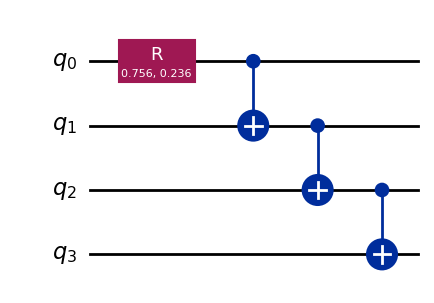

In [3]:
# define initial circuit

circuit = QuantumCircuit(4)

mult = 1.635
circuit.r(mult * 0.46262, mult * 0.1446, 0)
circuit.cx(0, 1)
circuit.cx(1, 2)
circuit.cx(2, 3)

circuit.draw("mpl")

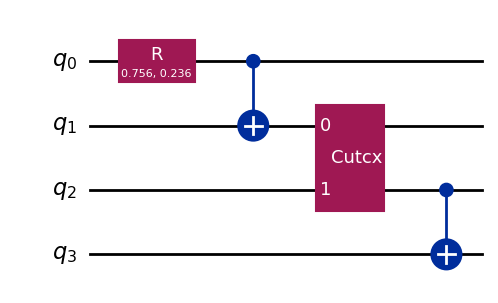

In [4]:
# insert cuts
cut_circuit = QuantumCircuit(4)

mult = 1.635
cut_circuit.r(mult * 0.46262, mult * 0.1446, 0)
cut_circuit.cx(0, 1)
cut_circuit.append(**cutGate(CXGate(), 1, 2))
cut_circuit.cx(2, 3)

cut_circuit.decompose(["CutGate"]).draw("mpl")

In [5]:
# extract cut locations and separate into subcircuits

cut_circuit = ck.get_locations_and_subcircuits(cut_circuit)

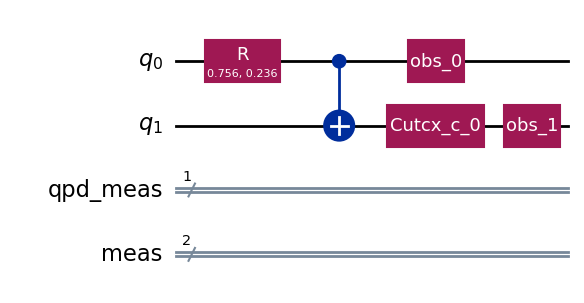

In [6]:
cut_circuit.subcircuits[0].draw("mpl")

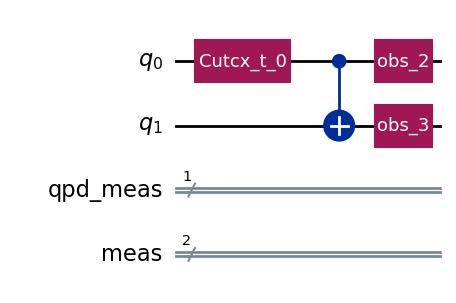

In [7]:
cut_circuit.subcircuits[1].draw("mpl")

In [9]:
# define backends
fake = IQMFakeAdonis()
sim = AerSimulator()

In [10]:
# transpile subcircuits for backend

transpiled = ck.transpile_subcircuits(cut_circuit, fake, optimization_level=3)

In [11]:
# generate experiment circuits
observables = SparsePauliOp(["IIIZ", "IIZI", "IZII", "IIZZ"])

cut_experiment = ck.get_experiment_circuits(transpiled, observables)

In [12]:
# run experiment circuits
# run_experiments() also post processes the results

results = ck.run_experiments(cut_experiment, backend=fake)

In [13]:
# get the approximated expectation values
expectation_values = ck.estimate_expectation_values(results)

In [14]:
obs = [ob.to_label() for ob in observables.paulis]

estimator = StatevectorEstimator()
exact_expvals = [
    e.data.evs
    for e in estimator.run([(x) for x in zip([circuit] * len(obs), obs)]).result()
]


tr = transpile(circuit, backend=fake)

tr_obs = observables.apply_layout(tr.layout)

tr_obs_separate = [SparsePauliOp(pauli.to_label()) for pauli in tr_obs.paulis]

fake_estimator = BackendEstimator(backend=fake)
exps = [
    e.data.evs
    for e in fake_estimator.run(
        [(x) for x in zip([tr] * len(tr_obs_separate), tr_obs_separate)]
    ).result()
]

In [15]:
import numpy as np

np.set_printoptions(formatter={"float": lambda x: f"{x:0.6f}"})

print(f"QCut expectation values:{np.array(expectation_values)}")
print(f"Noisy expectation values with fake backend:{np.array(exps)}")
print(f"Exact expectation values with ideal simulator :{np.array(exact_expvals)}")

QCut expectation values:[0.616615 0.673371 0.579371 0.819786]
Noisy expectation values with fake backend:[0.675293 0.569336 0.655273 0.754883]
Exact expectation values with ideal simulator :[0.727323 0.727323 0.727323 1.000000]
